In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [2]:
DATA_PATH = "./student_performance_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print("Dataset Shape: ")

print(df.shape)

Dataset Shape: 
(1000, 12)


In [4]:
# create column for binary divisor (in this analysis, did the student get a b or higher?
df['b_or_higher'] = np.where(df['final_grade'].isin(['A', 'B']), 1, 0)

In [5]:
print("Dataset Info\n")
df.info()

Dataset Info

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
 12  b_or_higher                 1000 non-null   int64  
dtypes: float64(5), int64(2), str(6)

In [6]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,b_or_higher
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A,1
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A,1
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A,1
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B,1
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D,0


In [7]:
# shuffle dataframe and split into train and test sets

shuffled_df = df.sample(frac=1).reset_index(drop=True)

# define columns of interest and create df from it
xs, ys = "final_exam_score", "b_or_higher"
selected_columns = [xs, ys]
selected_df = shuffled_df[selected_columns]

# 80/20 split
split = int(0.8 * len(df)) 

# create training set
train = selected_df[:split]

# use z-scores normalization to make the slope and bias each move with similar significance with each step
# without it, 
train_mean = np.mean(train[xs])
train_std = np.std(train[xs])
train[xs] = ((train[xs] - train_mean) / train_std)

test = selected_df[split:]
test[xs] = ((test[xs] - train_mean) / train_std)

print(train.shape)
print(test.shape)

(800, 2)
(200, 2)


In [8]:
#initialize random slope and bias to start

slope = random.uniform(-1, 1)
bias = random.uniform(-1, 1)

In [9]:
# run gradient descent 1000 times

for i in range(1000):
    # create predictions array
    preds = train[xs] * slope + bias

    # squash preds into probabilities using sigmoid
    probs = 1 / (1 + np.exp(-preds)) 

    # ensure no probabilities round to 1 or 0:
    probs = np.clip(probs, 1e-7, 1 - 1e-7)

    # take log loss
    loss = -np.mean(train[ys] * np.log(probs) + (1 - train[ys]) * np.log(1 - probs))
    
    
    # take derivative of loss wrt. preds (referred to as z here)
    dldz = probs - train[ys]

    # derivative of preds wrt. slope
    dzds = train[xs]
    
    # derivative of loss wrt. slope
    dlds = dldz * dzds
    
    slope_grads = dlds # relabelled
    
    
    # derivative of preds wrt. bias
    dzdb = 1
    # derivative of loss wrt. bias
    dldb = dldz * dzdb
    bias_grads = dldb
    

    # take average of gradients
    
    slope_grad_avg = (sum(slope_grads)) / len(slope_grads)
    
    bias_grad_avg = (sum(bias_grads)) / len(bias_grads)
    
            
    # nudge slope and bias in direction opposite to gradient

    step_size = 0.01
    
    slope -= (slope_grad_avg * step_size)
    
    bias -= (bias_grad_avg * step_size)
    
    
print(loss)

0.2682775883080206


In [10]:
# training scoring

probs_binary = (probs > 0.5).astype(int)
probs_binary

count = 0

for i, j in zip(probs_binary, train[ys]):
    if i == j:
        count += 1

count

796

In [11]:
np.sum(train[ys])

np.int64(513)

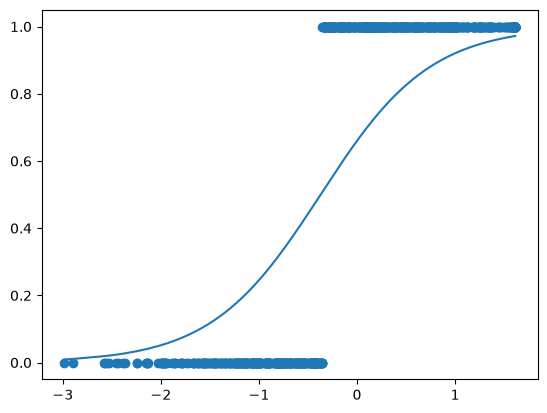

In [12]:
plt.scatter(train[xs], train[ys])

sort_idx = np.argsort(train[xs])
plt.plot(train[xs].values[sort_idx], probs.values[sort_idx])

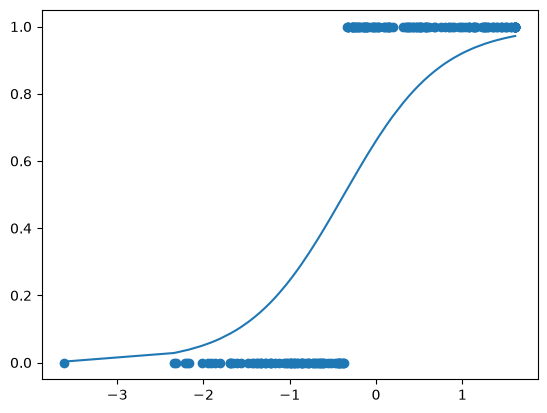

In [13]:
test_preds = test[xs] * slope + bias

test_probs = 1 / (1 + np.exp(-test_preds)) 


plt.scatter(test[xs], test[ys])

sort_idx = np.argsort(test[xs])
plt.plot(test[xs].values[sort_idx], test_probs.values[sort_idx])

In [14]:
# training scoring

test_probs_binary = (test_probs > 0.5).astype(int)
test_probs_binary

count = 0

for i, j in zip(test_probs_binary, test[ys]):
    if i == j:
        count += 1

count


200